## 📘 MILP Benchmark Problem: *pk1* (MIPLIB 2017)

### Problem Overview

The **pk1** instance is a benchmark **Mixed Integer Linear Programming (MILP)** problem from **MIPLIB 2017**, a widely used public library of challenging optimization problems for evaluating MILP solvers.

MIPLIB instances are derived from real-world applications or carefully constructed academic models and are commonly used in optimization research, solver development, and performance benchmarking.

🔗 Official problem page:  
https://miplib.zib.de/instance_details_pk1.html

---

### Mathematical Structure

The pk1 problem is formulated as a **linear optimization problem with discrete decision variables**, consisting of:

- A **linear objective function**
- **Linear equality and inequality constraints**
- A combination of **binary and continuous variables**

In the MPS formulation used in this notebook, the model contains:

- **86 decision variables**
  - **55 binary variables**
  - **31 general integer variables**
- **45 linear constraints**
- **915 nonzero coefficients** in the constraint matrix

No quadratic or nonlinear terms are present, making this a pure MILP.

---

### Objective Function

The objective is to minimize a linear cost function:

$$
\min \; c^\top x
$$

where $x$ represents the vector of decision variables and $c$ the corresponding cost coefficients.

The optimal objective value obtained by Gurobi in this notebook is:

$$
\boxed{z^* = 11.0}
$$

---

### Constraint Characteristics

All constraints are linear and enforce feasibility relationships among the decision variables.  
The problem structure leads to a **large integrality gap**, as evidenced by:

- Root LP relaxation objective value: **0.0**
- Optimal integer solution: **11.0**

This gap indicates that integrality plays a crucial role in determining feasible solutions, increasing the combinatorial difficulty of the problem.

---

### Solver Behavior and Difficulty

When solved using the **Gurobi Optimizer**, the pk1 instance exhibits typical MILP behavior:

- **Rapid early improvements** in feasible solutions due to primal heuristics
- **Slow tightening of the best bound** through branch-and-bound
- Most computational effort spent on **proving optimality**, rather than finding good solutions

The solver explores a large number of branch-and-bound nodes before closing the optimality gap, making pk1 a meaningful benchmark for studying solver convergence and performance diagnostics.

---

### Analysis Performed in This Notebook

This notebook focuses not only on solving the pk1 instance, but also on analyzing solver dynamics using callbacks. Specifically, we:

- Track **incumbent objective values** over time
- Track **best bound evolution**
- Compute and visualize the **relative MIP gap**
- Plot solver progress versus **time** and **branch-and-bound nodes**
- Use **logarithmic scales** to clearly illustrate convergence behavior

These analyses provide insight into how modern MILP solvers navigate large discrete search spaces.

---

### Why This Instance Is Included

The pk1 problem is well suited for a portfolio and benchmarking study because it:

- Is a standard, publicly documented benchmark
- Has moderate size but nontrivial combinatorial complexity
- Exhibits clear solver dynamics suitable for visualization
- Demonstrates practical use of solver callbacks and performance analysis

---



Read MPS format model from file /content/binary_continuous_pk1.mps
Reading time = 0.00 seconds
pk1: 45 rows, 86 columns, 915 nonzeros
Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 45 rows, 86 columns and 915 nonzeros (Min)
Model fingerprint: 0x2f6e3311
Model has 1 linear objective coefficients
Variable types: 31 continuous, 55 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 6e+01]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [7e+02, 7e+02]
Found heuristic solution: objective 675.0000000
Presolve time: 0.00s
Presolved: 45 rows, 86 columns, 915 nonzeros
Variable types: 31 continuous, 55 integer (55 binary)

Root relaxation: objective 0.000000e+00, 52 iterations, 0.00 seconds (0.00 w

/tmp/ipython-input-4008016580.py:61: RuntimeWarning: divide by zero encountered in log
  plt.plot(times, np.log(bounds), linestyle="--", label="Best bound")
/tmp/ipython-input-4008016580.py:61: RuntimeWarning: invalid value encountered in log
  plt.plot(times, np.log(bounds), linestyle="--", label="Best bound")


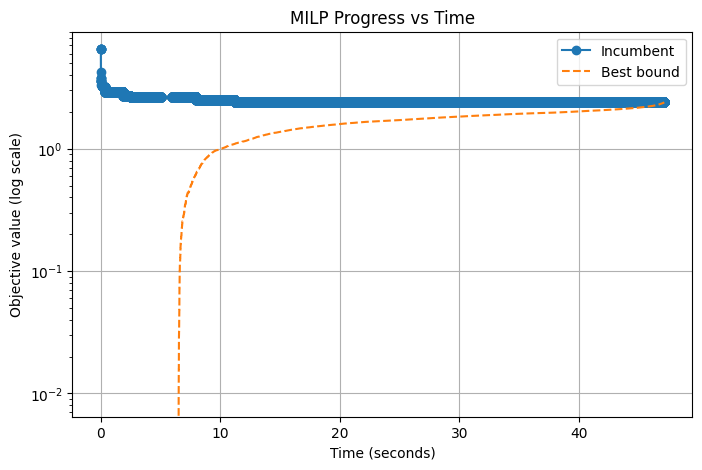

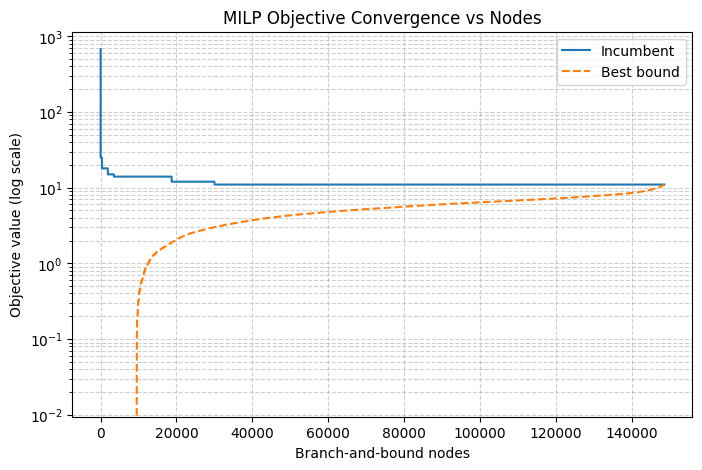

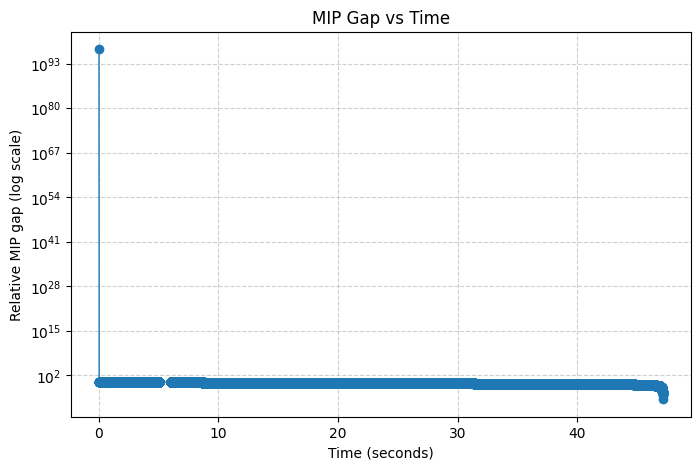

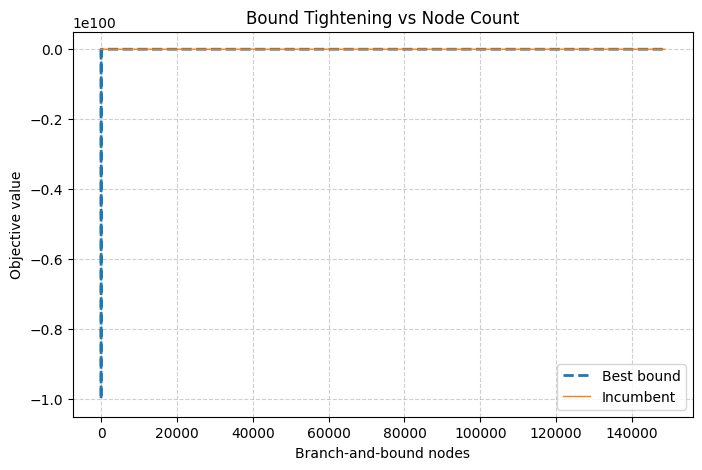

In [4]:
!pip -q install gurobipy

import os
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import numpy as np

mps_path = "/content/binary_continuous_pk1.mps"
if not os.path.exists(mps_path):
    raise FileNotFoundError(f"Not found: {mps_path}")

m = gp.read(mps_path)
m.Params.OutputFlag = 1

# --- storage ---
times = []
nodes = []
incumbents = []
bounds = []
events = []

def cb(model, where):
    # Record new feasible solutions (incumbent improvements)
    if where == GRB.Callback.MIPSOL:
        t = model.cbGet(GRB.Callback.RUNTIME)
        n = model.cbGet(GRB.Callback.MIPSOL_NODCNT)
        obj = model.cbGet(GRB.Callback.MIPSOL_OBJ)
        bnd = model.cbGet(GRB.Callback.MIPSOL_OBJBND)

        times.append(t); nodes.append(n)
        incumbents.append(obj); bounds.append(bnd)
        events.append("MIPSOL")

    # Record periodic progress (bound updates)
    elif where == GRB.Callback.MIP:
        t = model.cbGet(GRB.Callback.RUNTIME)
        n = model.cbGet(GRB.Callback.MIP_NODCNT)
        obj_best = model.cbGet(GRB.Callback.MIP_OBJBST)
        obj_bnd  = model.cbGet(GRB.Callback.MIP_OBJBND)

        if obj_best < GRB.INFINITY:
            times.append(t); nodes.append(n)
            incumbents.append(obj_best); bounds.append(obj_bnd)
            events.append("MIP")

# Run once with callback
m.optimize(cb)

print("Collected points:", len(times))
print("Status:", m.Status)
if m.SolCount > 0:
    print("Objective:", m.ObjVal)
    m.write("/content/solution.sol")
    m.write("/content/model_parsed.lp")
    print("Wrote: /content/solution.sol and /content/model_parsed.lp")

# ---- Plot: Objective vs time ----
plt.figure(figsize=(8,5))
plt.plot(times, np.log(incumbents), marker="o", label="Incumbent")
plt.plot(times, np.log(bounds), linestyle="--", label="Best bound")
plt.yscale("log")
plt.xlabel("Time (seconds)")
plt.ylabel("Objective value (log scale)")
plt.title("MILP Progress vs Time")
plt.grid(True)
plt.legend()
plt.show()

# ---- Plot: Objective vs nodes ----
plt.figure(figsize=(8,5))
plt.plot(nodes, incumbents, label="Incumbent")
plt.plot(nodes, bounds, linestyle="--", label="Best bound")

plt.yscale("log")
plt.xlabel("Branch-and-bound nodes")
plt.ylabel("Objective value (log scale)")
plt.title("MILP Objective Convergence vs Nodes")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.show()

# As the search for the optimum advnaces, the integrality gap minimizes.

# Convert to numpy arrays
t = np.asarray(times, dtype=float)
inc = np.asarray(incumbents, dtype=float)
bnd = np.asarray(bounds, dtype=float)

# Safety: keep only finite entries
mask = np.isfinite(t) & np.isfinite(inc) & np.isfinite(bnd)
t, inc, bnd = t[mask], inc[mask], bnd[mask]

# Relative gap for minimization
eps = 1e-12
gap = (inc - bnd) / np.maximum(np.abs(inc), eps)

# Clip to avoid log(0) and negative values due to numerical noise
gap = np.maximum(gap, 1e-12)

# Optional: sort by time (sometimes callback gives non-monotone due to mixed events)
order = np.argsort(t)
t, gap = t[order], gap[order]

plt.figure(figsize=(8,5))
plt.plot(t, gap, marker="o", linewidth=1)
plt.yscale("log")
plt.xlabel("Time (seconds)")
plt.ylabel("Relative MIP gap (log scale)")
plt.title("MIP Gap vs Time")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.show()

# plot for Node count vs Best bound (and optional incumbent)
# This plot shows how the lower bound tightens as branch-and-bound explores nodes

n = np.asarray(nodes, dtype=float)
inc = np.asarray(incumbents, dtype=float)
bnd = np.asarray(bounds, dtype=float)

mask = np.isfinite(n) & np.isfinite(inc) & np.isfinite(bnd)
n, inc, bnd = n[mask], inc[mask], bnd[mask]

# Sort by node count
order = np.argsort(n)
n, inc, bnd = n[order], inc[order], bnd[order]

plt.figure(figsize=(8,5))

# Best bound vs nodes (main request)
plt.plot(n, bnd, linestyle="--", linewidth=2, label="Best bound")

# Optional: include incumbent for context
plt.plot(n, inc, linewidth=1, label="Incumbent")

plt.xlabel("Branch-and-bound nodes")
plt.ylabel("Objective value")
plt.title("Bound Tightening vs Node Count")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()
